# Narrative × asset, v2.3.0: checks, measures and the GFC / Covid cases

Reads `narrative_asset_daily` of the one-pass run v2.3.0 with its siblings
`narrative_daily` and `asset_attention_daily` (pinned below; partial runs are fine). One
row per (DATE, SENTIMENT label, narrative_key, RP_ENTITY_ID) with at least one headline
that tags the entity AND scores on the narrative (sparse: no row = no support).

| columns | over the headlines tagging asset i and scored on narrative n |
|---|---|
| SUPPORT, TOTAL_SCORE, SUMSQ, PEAK | every such headline: count, Σ s, Σ s², max s |
| SUPPORT_REL, TOTAL_SCORE_REL, SUMSQ_REL, PEAK_REL | only RELEVANCE ≥ 60 (PEAK_REL null when SUPPORT_REL = 0) |
| TOTAL_SCORE_RELW, SUMSQ_RELW | weighted, w = RELEVANCE / 100: Σ s·w, Σ (s·w)² |

**Narrative level.** The two poles of every bipolar
pair are added into one narrative (key `reservoir|dimension|TYPE`); exact on this
`mask_bipolar` run, where a headline keeps at most one pole of a pair. Battery names
that name a pole stand for their merged narrative.

**Measures** (sums over a window W and a label set L first, then ratios):

| measure | definition | reads as |
|---|---|---|
| exposure | X(i,n) = Σ TOTAL_SCORE(i,n) / max(50, Σ N_STORIES(i)) | the mean narrative score of the asset's stories (non-hits score 0), shrunk toward 0 below 50 stories |
| se(X) | √[(Σ SUMSQ / N_i − X²) / N_i], N_i = Σ N_STORIES(i) | sampling error of X (stories as draws) |
| centrality | Σ TOTAL_SCORE(i,n) / Σ TOTAL_SCORE(n) | the asset's slice of the narrative (shares overlap: a headline tagging k assets counts for each) |
| lift | [Σ TOTAL_SCORE(i,n) / Σ N_STORIES(i)] / [Σ TOTAL_SCORE(n) / Σ N_HEADLINES] | how much more the asset's news carries n than the whole flow does |

Variants: `plain` (every headline), `rel` (*_REL over N_STORIES_REL), `relw` (Σ s·w over
REL_SUM: the relevance-weighted mean). Part 1 checks the table, Part 2 compares the
variants, Parts 3–4 are the GFC and Covid cases. Read-only.

In [ ]:
import os
from datetime import date, timedelta

import polars as pl
import matplotlib.pyplot as plt
from dotenv import find_dotenv, load_dotenv

from datalake import DatalakeIndex

load_dotenv(find_dotenv(usecwd=True))
pl.Config.set_tbl_rows(40); pl.Config.set_tbl_width_chars(220); pl.Config.set_fmt_str_lengths(50)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "figure.constrained_layout.use": True})

# ---- data -----------------------------------------------------------------------------
NARRATIVE_ASSET_ID = "narrative_asset_daily__v2.3.0__paramsfdb20afe__20261002"
ASSET_ATTENTION_ID = "asset_attention_daily__v2.3.0__paramsfdb20afe__20261002"
NARRATIVE_DAILY_ID = "narrative_daily__v2.3.0__paramsf17c46f2__20261002"
UNIVERSE_ID = "universe__v0.1.0__n_entries383947_namemsci_world_source_patha779a7db__20260929"
KEY = "narrative_key"
STUDIES = {                       # label sets: shares of the SAME daily flow (N_HEADLINES)
    "Attention": ("neg", "neu", "pos"),
    "Negative": ("neg",),
    "Positive + neutral": ("neu", "pos"),
}
RELEVANCE_FLOOR = 60              # min_relevance 0.6 on the vendor's 0-100 scale
SHRINK = 50                       # exposure denominator floor (stories)
MIN_SUPPORT = 20                  # pairs with fewer supporting headlines are not ranked
TOP_N = 15
CHECK_MONTH = "2008-09"           # Part 1-2: one month, the cross table is ~100-200 MB / month
CASE_VARIANT = "rel"              # Parts 3-4 (see 2.1: plain is dominated by passing mentions)

# ---- cases ----------------------------------------------------------------------------
GFC = {
    "window": (date(2008, 7, 1), date(2008, 12, 31)),     # 2008Q3-Q4
    "baseline": (date(2006, 7, 1), date(2007, 6, 30)),    # pre-crisis year
    "view": (date(2007, 1, 1), date(2009, 12, 31)),
    "events": {"BNP funds frozen": date(2007, 8, 9), "Bear Stearns": date(2008, 3, 14),
               "Lehman": date(2008, 9, 15), "Equity trough": date(2009, 3, 9)},
    "batteries": {                                        # same batteries as the GFC narrative study
        "funding / liquidity": ["funding-squeeze", "repo-and-money-market-dislocation", "liquidity-hoarding",
                                "cross-border-dollar-funding-stress", "collateral-scarcity-and-haircut-stress"],
        "systemic solvency": ["bank-run", "sifi-failure-risk", "systemic-capital-shortfall",
                              "systemic-fragility", "systemic-credit-spread-stress"],
        "housing bust": ["housing-bust"],
    },
    "names": {                                            # RavenPack entity ids (universe)
        "Lehman Brothers": "A78640", "AIG": "0BC29E", "Merrill Lynch": "75EE05",
        "Fannie Mae": "450647", "Freddie Mac": "CD4203", "Citigroup": "58CA9A",
        "Bank of America": "990AD0", "JPMorgan": "619882", "Goldman Sachs": "50070E",
        "Morgan Stanley": "9196A2",
    },
}
COVID = {
    "window": (date(2020, 2, 15), date(2020, 6, 30)),     # 2020Q1 crash -> Q2
    "baseline": (date(2019, 1, 1), date(2019, 12, 31)),
    "view": (date(2019, 7, 1), date(2021, 6, 30)),
    "events": {"Italy outbreak": date(2020, 2, 24), "WHO pandemic": date(2020, 3, 11),
               "Negative WTI": date(2020, 4, 20), "Pfizer efficacy": date(2020, 11, 9)},
    "batteries": {                                        # same batteries as the Covid narrative study
        "health shock": ["pandemic-and-epidemic-outbreak", "health-fear-and-contagion-salience",
                         "public-health-deterioration"],
        "oil / demand collapse": ["demand-destruction", "demand-driven-price-collapse", "supply-glut",
                                  "curve-contango", "producer-group-output-shift"],
        "supply chain": ["supply-chain-disruption", "logistics-and-transport-break",
                         "supply-chain-stress-attention", "product-shortage-and-outage",
                         "staffing-shortage", "input-supply-shock-attention"],
        "vaccine / health recovery": ["public-health-improvement", "product-approval",
                                      "approval-decision-attention", "feasibility-demonstration"],
    },
    "names": {
        "Delta": "5F2FF7", "American Airlines": "13C3E0", "United Airlines": "6E705B",
        "Carnival": "067779", "Royal Caribbean": "751A74", "Marriott": "385DD4",
        "Exxon": "E70531", "Chevron": "D54E62", "Occidental": "CA212F",
        "Zoom": "362955", "Moderna": "8EA478", "Pfizer": "267718",
    },
}

In [2]:
DL = DatalakeIndex(os.environ["DATALAKE_ROOT"], create=False)
na_art, aa_art, nd_art = DL.get(NARRATIVE_ASSET_ID), DL.get(ASSET_ATTENTION_ID), DL.get(NARRATIVE_DAILY_ID)
NA_FILES = sorted(na_art.path.glob("*.parquet"))
AA_FILES = sorted(aa_art.path.glob("*.parquet"))
ND_FILES = sorted(nd_art.path.glob("*.parquet"))
assert [f.stem for f in NA_FILES] == [f.stem for f in AA_FILES] == [f.stem for f in ND_FILES], \
    "the three tables cover different months"
print(f"{len(NA_FILES)} months, {NA_FILES[0].stem} .. {NA_FILES[-1].stem}; "
      f"cross table {sum(f.stat().st_size for f in NA_FILES) / 1e9:.1f} GB")

NA = pl.scan_parquet([str(f) for f in NA_FILES])      # lazy: always filter before collecting
AA = pl.scan_parquet([str(f) for f in AA_FILES])
ND = pl.scan_parquet([str(f) for f in ND_FILES])

UNIVERSE = pl.read_parquet([str(f) for f in DL.get(UNIVERSE_ID).files("*.parquet")])
ENTITIES = (UNIVERSE.drop_nulls("rp_entity_id").sort("snapshot_date")
            .unique("rp_entity_id", keep="last")
            .select(pl.col("rp_entity_id").alias("RP_ENTITY_ID"), "name", "ticker", "gics_sector"))
for case in (GFC, COVID):
    missing = set(case["names"].values()) - set(ENTITIES["RP_ENTITY_ID"].to_list())
    assert not missing, f"case entities not in the universe: {missing}"

245 months, 2000-04 .. 2020-08; cross table 27.0 GB


## Narrative level: pole keys → merged keys

The narrative nodes are read from narrative_daily (identity columns only). A
(reservoir, dimension, TYPE) group with exactly two signed poles is a bipolar pair: both
pole keys map to `reservoir|dimension|TYPE` (the rule of `validation.merge_poles`); every
other key maps to itself. `NAME_TO_KEYS` maps narrative names, pole names included, to
merged keys, for the batteries.

In [3]:
NODES = (ND.select("reservoir", "dimension", "TYPE", "narrative", "pole", KEY).unique().collect()
         .with_columns(pl.col("pole").fill_null("")))
pairs = (NODES.filter(pl.col("pole") != "").group_by("reservoir", "dimension", "TYPE")
         .agg(pl.col("pole").n_unique().alias("n_poles")).filter(pl.col("n_poles") == 2)
         .with_columns(pl.lit(True).alias("is_pair")).drop("n_poles"))
NODES = (NODES.join(pairs, on=["reservoir", "dimension", "TYPE"], how="left")
         .with_columns(pl.when(pl.col("is_pair").fill_null(False))
                       .then(pl.concat_str("reservoir", "dimension", "TYPE", separator="|"))
                       .otherwise(pl.col(KEY)).alias("MERGED"),
                       pl.when(pl.col("is_pair").fill_null(False)).then(pl.col("TYPE"))
                       .otherwise(pl.col("narrative")).alias("merged_name")))
KEYMAP = NODES.select(KEY, "MERGED")
assert KEYMAP[KEY].n_unique() == KEYMAP.height, "a narrative_key maps to two merged keys"
MERGED_NAMES = NODES.select("MERGED", "merged_name", "reservoir", "dimension").unique("MERGED")
NAME_TO_KEYS: dict[str, list[str]] = {}
for col in ("narrative", "merged_name"):
    for name, g in NODES.group_by(col):
        NAME_TO_KEYS.setdefault(name[0], [])
        NAME_TO_KEYS[name[0]] = sorted(set(NAME_TO_KEYS[name[0]]) | set(g["MERGED"].to_list()))
print(f"{NODES[KEY].n_unique()} narrative x pole keys -> {NODES['MERGED'].n_unique()} narratives "
      f"({pairs.height} bipolar pairs merged)")


def battery_keys(names) -> list[str]:
    # merged keys of a battery's names; unknown names reported
    unknown = [n for n in names if n not in NAME_TO_KEYS]
    if unknown:
        print(f"  not in the taxonomy: {unknown}")
    return sorted({k for n in names if n in NAME_TO_KEYS for k in NAME_TO_KEYS[n]})

419 narrative x pole keys -> 368 narratives (51 bipolar pairs merged)


# Part 1: checks (one month, `CHECK_MONTH`)

## 1.1 Keys and invariants of the cross table

Expected on every row: unique (DATE, SENTIMENT, narrative_key, RP_ENTITY_ID);
SUPPORT ≥ 1; SUPPORT_REL ≤ SUPPORT; TOTAL_SCORE_REL ≤ TOTAL_SCORE; PEAK_REL ≤ PEAK;
PEAK_REL null ⇔ SUPPORT_REL = 0; SUMSQ ≥ TOTAL_SCORE² / SUPPORT (Cauchy–Schwarz);
PEAK · SUPPORT ≥ TOTAL_SCORE; 0.6 · TOTAL_SCORE_REL ≤ TOTAL_SCORE_RELW ≤ TOTAL_SCORE.

In [4]:
na_m = pl.scan_parquet(str(na_art.path / f"{CHECK_MONTH}.parquet"))
aa_m = pl.scan_parquet(str(aa_art.path / f"{CHECK_MONTH}.parquet"))
nd_m = pl.scan_parquet(str(nd_art.path / f"{CHECK_MONTH}.parquet"))
eps = 1e-6
inv = na_m.select(
    pl.len().alias("rows"),
    (pl.col("SUPPORT") < 1).sum().alias("support_lt_1"),
    (pl.col("SUPPORT_REL") > pl.col("SUPPORT")).sum().alias("support_rel_gt"),
    (pl.col("TOTAL_SCORE_REL") > pl.col("TOTAL_SCORE") + eps).sum().alias("total_rel_gt"),
    (pl.col("PEAK_REL") > pl.col("PEAK") + eps).sum().alias("peak_rel_gt"),
    (pl.col("PEAK_REL").is_null() != (pl.col("SUPPORT_REL") == 0)).sum().alias("peak_rel_null_mismatch"),
    (pl.col("SUMSQ") < pl.col("TOTAL_SCORE") ** 2 / pl.col("SUPPORT") - eps).sum().alias("cauchy_schwarz"),
    (pl.col("PEAK") * pl.col("SUPPORT") < pl.col("TOTAL_SCORE") - eps).sum().alias("peak_times_n_lt_total"),
    (pl.col("TOTAL_SCORE_RELW") > pl.col("TOTAL_SCORE") + eps).sum().alias("relw_gt_total"),
    (pl.col("TOTAL_SCORE_RELW") < RELEVANCE_FLOOR / 100 * pl.col("TOTAL_SCORE_REL") - eps).sum().alias("relw_lt_floor"),
).collect()
print(inv)
dups = (na_m.group_by("DATE", "SENTIMENT", KEY, "RP_ENTITY_ID").len().filter(pl.col("len") > 1)
        .select(pl.len()).collect().item())
print(f"duplicated keys: {dups}")
bad = inv.drop("rows").transpose(include_header=True).filter(pl.col("column_0") > 0)
print("invariants: all hold" if bad.is_empty() and dups == 0 else f"VIOLATED:\n{bad}")

shape: (1, 10)
┌─────────┬──────────────┬────────────────┬──────────────┬───┬────────────────┬───────────────────────┬───────────────┬───────────────┐
│ rows    ┆ support_lt_1 ┆ support_rel_gt ┆ total_rel_gt ┆ … ┆ cauchy_schwarz ┆ peak_times_n_lt_total ┆ relw_gt_total ┆ relw_lt_floor │
│ ---     ┆ ---          ┆ ---            ┆ ---          ┆   ┆ ---            ┆ ---                   ┆ ---           ┆ ---           │
│ u32     ┆ u32          ┆ u32            ┆ u32          ┆   ┆ u32            ┆ u32                   ┆ u32           ┆ u32           │
╞═════════╪══════════════╪════════════════╪══════════════╪═══╪════════════════╪═══════════════════════╪═══════════════╪═══════════════╡
│ 3385385 ┆ 0            ┆ 0              ┆ 0            ┆ … ┆ 0              ┆ 0                     ┆ 0             ┆ 560319        │
└─────────┴──────────────┴────────────────┴──────────────┴───┴────────────────┴───────────────────────┴───────────────┴───────────────┘
duplicated keys: 0
VIOLATED:
shap

## 1.2 Consistency with narrative_daily and asset_attention_daily

A cross cell is a subset of both margins, so per row: SUPPORT(i,n) ≤ SUPPORT(n),
TOTAL_SCORE(i,n) ≤ TOTAL_SCORE(n), PEAK(i,n) ≤ PEAK(n) (narrative_daily, same day and
label), SUPPORT(i,n) ≤ N_STORIES(i), SUPPORT_REL(i,n) ≤ N_STORIES_REL(i) (asset table);
every (DATE, SENTIMENT, asset) of the cross table has an asset row, with the same
IN_UNIVERSE, N_HEADLINES and N_LABELLED.

Σ over assets of SUPPORT(i,n) is NOT bounded by SUPPORT(n): a headline tagging k assets
counts k times. Its ratio to SUPPORT(n) is shown instead (`assets_per_supporting_headline`,
a lower bound on the mean: headlines with no universe asset are in SUPPORT(n) only).

In [5]:
x = (na_m.join(nd_m.select("DATE", "SENTIMENT", KEY, pl.col("SUPPORT").alias("S_n"),
                           pl.col("TOTAL_SCORE").alias("T_n"), pl.col("PEAK").alias("P_n")),
               on=["DATE", "SENTIMENT", KEY], how="left")
     .join(aa_m.select("DATE", "SENTIMENT", "RP_ENTITY_ID", "N_STORIES", "N_STORIES_REL",
                       pl.col("IN_UNIVERSE").alias("IN_UNIVERSE_A"), pl.col("N_HEADLINES").alias("N_HEADLINES_A"),
                       pl.col("N_LABELLED").alias("N_LABELLED_A")),
           on=["DATE", "SENTIMENT", "RP_ENTITY_ID"], how="left"))
cons = x.select(
    pl.col("S_n").is_null().sum().alias("no_narrative_row"),
    pl.col("N_STORIES").is_null().sum().alias("no_asset_row"),
    (pl.col("SUPPORT") > pl.col("S_n")).sum().alias("support_gt_narrative"),
    (pl.col("TOTAL_SCORE") > pl.col("T_n") + eps).sum().alias("total_gt_narrative"),
    (pl.col("PEAK") > pl.col("P_n") + eps).sum().alias("peak_gt_narrative"),
    (pl.col("SUPPORT") > pl.col("N_STORIES")).sum().alias("support_gt_stories"),
    (pl.col("SUPPORT_REL") > pl.col("N_STORIES_REL")).sum().alias("support_rel_gt_stories_rel"),
    (pl.col("IN_UNIVERSE").ne_missing(pl.col("IN_UNIVERSE_A"))).sum().alias("in_universe_mismatch"),
    (pl.col("N_HEADLINES") != pl.col("N_HEADLINES_A")).sum().alias("n_headlines_mismatch"),
    (pl.col("N_LABELLED") != pl.col("N_LABELLED_A")).sum().alias("n_labelled_mismatch"),
).collect()
print(cons)
ratio = (na_m.group_by("DATE", "SENTIMENT", KEY).agg(pl.col("SUPPORT").sum().alias("S_cross"))
         .join(nd_m.select("DATE", "SENTIMENT", KEY, "SUPPORT"), on=["DATE", "SENTIMENT", KEY])
         .select((pl.col("S_cross").sum() / pl.col("SUPPORT").sum()).alias("assets_per_supporting_headline"))
         .collect().item())
print(f"assets_per_supporting_headline ({CHECK_MONTH}): {ratio:.3f}")

shape: (1, 10)
┌──────────────────┬──────────────┬──────────────────────┬────────────────────┬───┬────────────────────────────┬──────────────────────┬──────────────────────┬─────────────────────┐
│ no_narrative_row ┆ no_asset_row ┆ support_gt_narrative ┆ total_gt_narrative ┆ … ┆ support_rel_gt_stories_rel ┆ in_universe_mismatch ┆ n_headlines_mismatch ┆ n_labelled_mismatch │
│ ---              ┆ ---          ┆ ---                  ┆ ---                ┆   ┆ ---                        ┆ ---                  ┆ ---                  ┆ ---                 │
│ u32              ┆ u32          ┆ u32                  ┆ u32                ┆   ┆ u32                        ┆ u32                  ┆ u32                  ┆ u32                 │
╞══════════════════╪══════════════╪══════════════════════╪════════════════════╪═══╪════════════════════════════╪══════════════════════╪══════════════════════╪═════════════════════╡
│ 0                ┆ 0            ┆ 0                    ┆ 0                  ┆ 

## 1.3 Size and sparsity

Rows per day and file size per month over the whole run (file metadata only), and for
the check month: distinct narratives, assets and pairs per day.

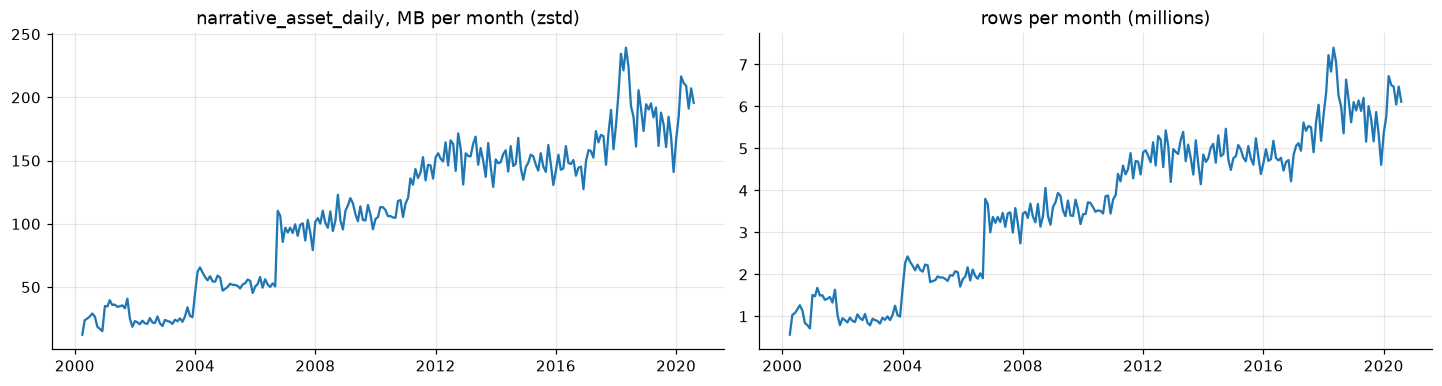

total 27.0 GB, 0.89 bn rows
shape: (9, 5)
┌────────────┬─────────────────────┬───────────────┬────────────┬─────────────┐
│ statistic  ┆ DATE                ┆ rows          ┆ narratives ┆ assets      │
│ ---        ┆ ---                 ┆ ---           ┆ ---        ┆ ---         │
│ str        ┆ str                 ┆ f64           ┆ f64        ┆ f64         │
╞════════════╪═════════════════════╪═══════════════╪════════════╪═════════════╡
│ count      ┆ 30                  ┆ 30.0          ┆ 30.0       ┆ 30.0        │
│ null_count ┆ 0                   ┆ 0.0           ┆ 0.0        ┆ 0.0         │
│ mean       ┆ 2008-09-15 12:00:00 ┆ 112846.166667 ┆ 419.0      ┆ 1610.866667 │
│ std        ┆ null                ┆ 47901.686567  ┆ 0.0        ┆ 475.686563  │
│ min        ┆ 2008-09-01          ┆ 32780.0       ┆ 419.0      ┆ 704.0       │
│ 25%        ┆ 2008-09-08          ┆ 41427.0       ┆ 419.0      ┆ 1030.0      │
│ 50%        ┆ 2008-09-16          ┆ 139710.0      ┆ 419.0      ┆ 1864.0      

In [6]:
sizes = pl.DataFrame({"month": [f.stem for f in NA_FILES],
                      "cross_MB": [f.stat().st_size / 1e6 for f in NA_FILES],
                      "asset_MB": [f.stat().st_size / 1e6 for f in AA_FILES]})
rows_month = pl.DataFrame({"month": [f.stem for f in NA_FILES],
                           "rows": [pl.scan_parquet(str(f)).select(pl.len()).collect().item() for f in NA_FILES]})
sizes = sizes.join(rows_month, on="month").with_columns(pl.col("month").str.to_date("%Y-%m"))
fig, ax = plt.subplots(1, 2, figsize=(13, 3.4))
ax[0].plot(sizes["month"], sizes["cross_MB"]); ax[0].set_title("narrative_asset_daily, MB per month (zstd)")
ax[1].plot(sizes["month"], sizes["rows"] / 1e6); ax[1].set_title("rows per month (millions)")
plt.show()
print(f"total {sizes['cross_MB'].sum() / 1e3:.1f} GB, {sizes['rows'].sum() / 1e9:.2f} bn rows")
print(na_m.group_by("DATE").agg(pl.len().alias("rows"), pl.col(KEY).n_unique().alias("narratives"),
                                pl.col("RP_ENTITY_ID").n_unique().alias("assets"))
      .collect().describe())

# Part 2: measures and variants

`pair_sums(window, labels, keys=, ids=)` aggregates the cross table to (asset, merged
narrative) over the window: poles are added (SUPPORT, TOTAL_SCORE, SUMSQ and their
variants are sums; PEAK max). `measures(...)` joins the asset denominators (Σ N_STORIES,
Σ N_STORIES_REL, Σ REL_SUM of the same labels and window), the narrative totals
(narrative_daily, poles merged) and Σ N_HEADLINES, and returns exposure, se, centrality,
lift for one variant. Filter by `keys` and/or `ids` whenever the window is long: a quarter
of the unfiltered cross table is tens of millions of rows.

In [7]:
SUM_COLS = ["SUPPORT", "TOTAL_SCORE", "SUMSQ", "SUPPORT_REL", "TOTAL_SCORE_REL", "SUMSQ_REL",
            "TOTAL_SCORE_RELW", "SUMSQ_RELW"]
VARIANTS = {   # variant -> (numerator, sum of squares, denominator in asset_attention, support)
    "plain": ("TOTAL_SCORE", "SUMSQ", "N_STORIES", "SUPPORT"),
    "rel": ("TOTAL_SCORE_REL", "SUMSQ_REL", "N_STORIES_REL", "SUPPORT_REL"),
    "relw": ("TOTAL_SCORE_RELW", "SUMSQ_RELW", "REL_SUM", "SUPPORT"),
}


def _between(window):
    return pl.col("DATE").is_between(*window)


def pair_sums(window, labels, keys=None, ids=None, frame=None) -> pl.DataFrame:
    # (RP_ENTITY_ID, MERGED) sums over the window and labels; `keys` are MERGED keys
    src = NA if frame is None else frame
    q = src.filter(_between(window), pl.col("SENTIMENT").is_in(list(labels)))
    if keys is not None:
        raw = KEYMAP.filter(pl.col("MERGED").is_in(list(keys)))[KEY].to_list()
        q = q.filter(pl.col(KEY).is_in(raw))
    if ids is not None:
        q = q.filter(pl.col("RP_ENTITY_ID").is_in(list(ids)))
    return (q.join(KEYMAP.lazy(), on=KEY, how="left")
            .group_by("RP_ENTITY_ID", "MERGED")
            .agg(*[pl.col(c).sum() for c in SUM_COLS], pl.col("PEAK").max())
            .collect())


def asset_sums(window, labels, ids=None, frame=None) -> pl.DataFrame:
    src = AA if frame is None else frame
    q = src.filter(_between(window), pl.col("SENTIMENT").is_in(list(labels)))
    if ids is not None:
        q = q.filter(pl.col("RP_ENTITY_ID").is_in(list(ids)))
    return (q.group_by("RP_ENTITY_ID")
            .agg(pl.col("N_STORIES").sum(), pl.col("N_STORIES_REL").sum(), pl.col("REL_SUM").sum())
            .collect())


def narrative_sums(window, labels, frame=None) -> tuple[pl.DataFrame, int]:
    # merged narratives' Σ TOTAL_SCORE over the window and labels, and Σ N_HEADLINES (days)
    src = ND if frame is None else frame
    q = src.filter(_between(window))
    heads = (q.group_by("DATE").agg(pl.col("N_HEADLINES").first()).select(pl.col("N_HEADLINES").sum())
             .collect().item())
    tot = (q.filter(pl.col("SENTIMENT").is_in(list(labels))).join(KEYMAP.lazy(), on=KEY, how="left")
           .group_by("MERGED").agg(pl.col("TOTAL_SCORE").sum().alias("T_n"), pl.col("SUPPORT").sum().alias("S_n"))
           .collect())
    return tot, int(heads or 0)


def measures(window, labels, variant="plain", keys=None, ids=None, frames=(None, None, None)) -> pl.DataFrame:
    num, sq, den, sup = VARIANTS[variant]
    p = pair_sums(window, labels, keys, ids, frames[0])
    if p.is_empty():
        print(f"no cross rows in {window[0]} .. {window[1]}")
        return p
    a = asset_sums(window, labels, ids, frames[1])
    n, heads = narrative_sums(window, labels, frames[2])
    out = (p.join(a, on="RP_ENTITY_ID", how="left").join(n, on="MERGED", how="left")
           .with_columns(pl.col(num).alias("T"), pl.col(sq).alias("Q"), pl.col(den).alias("N_i"),
                         pl.col(sup).alias("S"))
           .with_columns(
               (pl.col("T") / pl.max_horizontal(pl.col("N_i"), pl.lit(SHRINK))).alias("exposure"),
               ((pl.col("Q") / pl.col("N_i") - (pl.col("T") / pl.col("N_i")) ** 2).clip(0)
                / pl.col("N_i")).sqrt().alias("se"),
               (pl.col("T") / pl.col("T_n")).alias("centrality"),
               ((pl.col("T") / pl.col("N_i")) / (pl.col("T_n") / heads)).alias("lift"))
           .join(ENTITIES, on="RP_ENTITY_ID", how="left")
           .join(MERGED_NAMES, on="MERGED", how="left"))
    return out


SHOW = ["name", "ticker", "merged_name", "S", "SUPPORT", "SUPPORT_REL", "N_i",
        "exposure", "se", "centrality", "lift"]


def fmt(frame: pl.DataFrame) -> pl.DataFrame:
    return frame.select([c for c in SHOW if c in frame.columns]).with_columns(
        pl.col("exposure", "se").round(4), pl.col("centrality").round(4), pl.col("lift").round(1))

## 2.1 Variants on the check month

Rank agreement (Spearman) of exposure across plain / rel / relw, over the pairs with
SUPPORT ≥ `MIN_SUPPORT` in the month (all labels). High agreement means the relevance
floor changes levels, not the ordering; the pairs that move the most are listed.

Probe on 2008-09 (written before the full run): plain~rel 0.40, plain~relw 0.94,
rel~relw 0.57. The plain top pairs were names tagged in passing in list-type headlines
(relevant support 0), and publishers (Thomson Reuters) were central to every crisis
narrative. The cases below therefore use `CASE_VARIANT = "rel"`; relw stays close to
plain because low-relevance stories still carry weight 0.2-0.5.

80,932 pairs with SUPPORT >= 20 in 2008-09
shape: (1, 3)
┌───────────┬────────────┬──────────┐
│ plain~rel ┆ plain~relw ┆ rel~relw │
│ ---       ┆ ---        ┆ ---      │
│ f64       ┆ f64        ┆ f64      │
╞═══════════╪════════════╪══════════╡
│ 0.401012  ┆ 0.943058   ┆ 0.571672 │
└───────────┴────────────┴──────────┘
shape: (15, 8)
┌────────────────────────┬─────────────────────────────────────┬─────────┬──────────┬──────────┬──────────┬─────────┬─────────┐
│ name                   ┆ merged_name                         ┆ SUPPORT ┆ x_plain  ┆ x_rel    ┆ x_relw   ┆ r_plain ┆ r_rel   │
│ ---                    ┆ ---                                 ┆ ---     ┆ ---      ┆ ---      ┆ ---      ┆ ---     ┆ ---     │
│ str                    ┆ str                                 ┆ i32     ┆ f64      ┆ f64      ┆ f64      ┆ f64     ┆ f64     │
╞════════════════════════╪═════════════════════════════════════╪═════════╪══════════╪══════════╪══════════╪═════════╪═════════╡
│ Moody's Corporation 

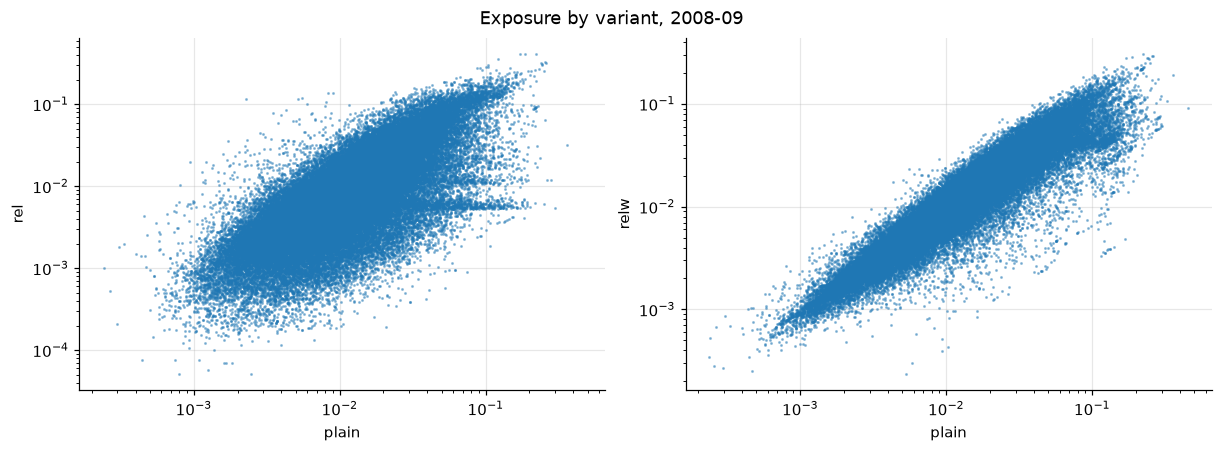

In [8]:
y, m = map(int, CHECK_MONTH.split("-"))
month_win = (date(y, m, 1), date(y + (m == 12), m % 12 + 1, 1) - timedelta(days=1))
month_frames = (na_m, aa_m, nd_m)
var = {v: measures(month_win, STUDIES["Attention"], v, frames=month_frames) for v in VARIANTS}
cmpv = (var["plain"].filter(pl.col("SUPPORT") >= MIN_SUPPORT)
        .select("RP_ENTITY_ID", "MERGED", "name", "merged_name", "SUPPORT", pl.col("exposure").alias("x_plain"))
        .join(var["rel"].select("RP_ENTITY_ID", "MERGED", pl.col("exposure").alias("x_rel")), on=["RP_ENTITY_ID", "MERGED"])
        .join(var["relw"].select("RP_ENTITY_ID", "MERGED", pl.col("exposure").alias("x_relw")), on=["RP_ENTITY_ID", "MERGED"]))
print(f"{cmpv.height:,} pairs with SUPPORT >= {MIN_SUPPORT} in {CHECK_MONTH}")
print(cmpv.select(pl.corr("x_plain", "x_rel", method="spearman").alias("plain~rel"),
                  pl.corr("x_plain", "x_relw", method="spearman").alias("plain~relw"),
                  pl.corr("x_rel", "x_relw", method="spearman").alias("rel~relw")))
moved = (cmpv.with_columns(pl.col("x_plain").rank(descending=True).alias("r_plain"),
                           pl.col("x_rel").rank(descending=True).alias("r_rel"))
         .with_columns((pl.col("r_rel") - pl.col("r_plain")).abs().alias("Δrank"))
         .sort("Δrank", descending=True).head(TOP_N))
print(moved.select("name", "merged_name", "SUPPORT", "x_plain", "x_rel", "x_relw", "r_plain", "r_rel"))
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].loglog(cmpv["x_plain"], cmpv["x_rel"], ".", ms=2, alpha=0.4); ax[0].set_xlabel("plain"); ax[0].set_ylabel("rel")
ax[1].loglog(cmpv["x_plain"], cmpv["x_relw"], ".", ms=2, alpha=0.4); ax[1].set_xlabel("plain"); ax[1].set_ylabel("relw")
fig.suptitle(f"Exposure by variant, {CHECK_MONTH}")
plt.show()

## 2.2 What the measures rank on the check month

Top pairs by exposure, by centrality (narratives with Σ SUPPORT(n) ≥ 200) and by lift
(pairs with S ≥ `MIN_SUPPORT`, S the variant's support), plain then rel: exposure favours names whose news is about the
narrative, centrality the names that dominate a narrative, lift both corrected for size.

In [9]:
for v in ("plain", "rel"):
    pm = var[v]
    print(f"\n##### variant {v} (S = {VARIANTS[v][3]}, N_i = {VARIANTS[v][2]})")
    print("exposure:\n", fmt(pm.filter(pl.col("S") >= MIN_SUPPORT).sort("exposure", descending=True).head(TOP_N)))
    print("centrality:\n", fmt(pm.filter(pl.col("S_n") >= 200).sort("centrality", descending=True).head(TOP_N)))
    print("lift:\n", fmt(pm.filter(pl.col("S") >= MIN_SUPPORT).sort("lift", descending=True).head(TOP_N)))


##### variant plain (S = SUPPORT, N_i = N_STORIES)
exposure:
 shape: (15, 11)
┌────────────────────────┬────────┬─────────────────────────────────────┬─────┬───┬──────────┬────────┬────────────┬───────┐
│ name                   ┆ ticker ┆ merged_name                         ┆ S   ┆ … ┆ exposure ┆ se     ┆ centrality ┆ lift  │
│ ---                    ┆ ---    ┆ ---                                 ┆ --- ┆   ┆ ---      ┆ ---    ┆ ---        ┆ ---   │
│ str                    ┆ str    ┆ str                                 ┆ i32 ┆   ┆ f64      ┆ f64    ┆ f64        ┆ f64   │
╞════════════════════════╪════════╪═════════════════════════════════════╪═════╪═══╪══════════╪════════╪════════════╪═══════╡
│ Entegris, Inc.         ┆ ENTG   ┆ earnings                            ┆ 67  ┆ … ┆ 0.4543   ┆ 0.0211 ┆ 0.0025     ┆ 35.4  │
│ Archrock, Inc.         ┆ AROC   ┆ earnings                            ┆ 92  ┆ … ┆ 0.3594   ┆ 0.0183 ┆ 0.003      ┆ 28.0  │
│ Energen Corporation    ┆ EGN    ┆ earnings  

# Part 3: GFC (2008Q3–Q4)

## 3.1 The most central stocks of the crisis batteries

All case tables use `CASE_VARIANT` (rel: RELEVANCE ≥ 60 stories; set "plain" to compare).
Per battery, the battery's narratives are pooled (Σ over its merged narratives of the
numerators and of the narrative totals), then centrality and exposure per asset, window vs
the 2006H2–2007H1 baseline. Expected: Lehman, AIG, the GSEs and the big banks hold most of
funding / solvency, the GSEs and homebuilders housing.

In [10]:
def battery_table(case, battery, labels, variant=CASE_VARIANT) -> pl.DataFrame:
    keys = battery_keys(case["batteries"][battery])
    out = []
    for tag, win in (("base", case["baseline"]), ("window", case["window"])):
        m = measures(win, labels, variant, keys=keys)
        if m.is_empty():
            return m
        n_tot = narrative_sums(win, labels)[0].filter(pl.col("MERGED").is_in(keys))["T_n"].sum()
        out.append(m.group_by("RP_ENTITY_ID")
                   .agg(pl.col("T").sum(), pl.col("S").sum(), pl.col("N_i").first())
                   .with_columns((pl.col("T") / n_tot).alias(f"centrality_{tag}"),
                                 (pl.col("T") / pl.max_horizontal(pl.col("N_i"), pl.lit(SHRINK))).alias(f"exposure_{tag}"),
                                 pl.col("S").alias(f"support_{tag}"))
                   .select("RP_ENTITY_ID", f"centrality_{tag}", f"exposure_{tag}", f"support_{tag}"))
    return (out[1].join(out[0], on="RP_ENTITY_ID", how="left").join(ENTITIES, on="RP_ENTITY_ID", how="left")
            .sort("centrality_window", descending=True).head(TOP_N)
            .select("name", "ticker", "gics_sector", "support_window",
                    pl.col("centrality_window").round(4), pl.col("centrality_base").round(4),
                    pl.col("exposure_window").round(4), pl.col("exposure_base").round(4)))


for battery in GFC["batteries"]:
    print(f"\n=== {battery} (Attention) ===")
    print(battery_table(GFC, battery, STUDIES["Attention"]))


=== funding / liquidity (Attention) ===
shape: (15, 8)
┌────────────────────────────────────────┬────────┬─────────────┬────────────────┬───────────────────┬─────────────────┬─────────────────┬───────────────┐
│ name                                   ┆ ticker ┆ gics_sector ┆ support_window ┆ centrality_window ┆ centrality_base ┆ exposure_window ┆ exposure_base │
│ ---                                    ┆ ---    ┆ ---         ┆ ---            ┆ ---               ┆ ---             ┆ ---             ┆ ---           │
│ str                                    ┆ str    ┆ str         ┆ i32            ┆ f64               ┆ f64             ┆ f64             ┆ f64           │
╞════════════════════════════════════════╪════════╪═════════════╪════════════════╪═══════════════════╪═════════════════╪═════════════════╪═══════════════╡
│ Citigroup Inc.                         ┆ C      ┆ Financials  ┆ 13535          ┆ 0.0224            ┆ 0.0057          ┆ 0.104           ┆ 0.0403        │
│ Lehman Broth

## 3.2 What the banks' news was about

Per institution, the merged narratives with the highest exposure in the window (SUPPORT ≥
`MIN_SUPPORT`), with their baseline exposure: the crisis should replace earnings /
deal-making narratives by funding, solvency and rescue ones.

In [11]:
def top_narratives(case, labels, variant=CASE_VARIANT, n=8) -> dict[str, pl.DataFrame]:
    ids = list(case["names"].values())
    win = measures(case["window"], labels, variant, ids=ids)
    if win.is_empty():
        return {}
    base = measures(case["baseline"], labels, variant, ids=ids).select(
        "RP_ENTITY_ID", "MERGED", pl.col("exposure").alias("exposure_base"))
    win = win.join(base, on=["RP_ENTITY_ID", "MERGED"], how="left")
    out = {}
    for label, eid in case["names"].items():
        out[label] = (win.filter(pl.col("RP_ENTITY_ID") == eid, pl.col("S") >= MIN_SUPPORT)
                      .sort("exposure", descending=True).head(n)
                      .select("merged_name", "dimension", "S", pl.col("exposure").round(4),
                              pl.col("se").round(4), pl.col("exposure_base").round(4), pl.col("lift").round(1)))
    return out


for label, t in top_narratives(GFC, STUDIES["Attention"]).items():
    print(f"\n--- {label} ---")
    print(t)


--- Lehman Brothers ---
shape: (8, 7)
┌─────────────────────────────────┬────────────────────────────────────┬──────┬──────────┬────────┬───────────────┬──────┐
│ merged_name                     ┆ dimension                          ┆ S    ┆ exposure ┆ se     ┆ exposure_base ┆ lift │
│ ---                             ┆ ---                                ┆ ---  ┆ ---      ┆ ---    ┆ ---           ┆ ---  │
│ str                             ┆ str                                ┆ i32  ┆ f64      ┆ f64    ┆ f64           ┆ f64  │
╞═════════════════════════════════╪════════════════════════════════════╪══════╪══════════╪════════╪═══════════════╪══════╡
│ credit                          ┆ aggregate-credit-activity          ┆ 7253 ┆ 0.0684   ┆ 0.0007 ┆ 0.0371        ┆ 4.7  │
│ bank-balance-sheet              ┆ intermediation-capacity            ┆ 7459 ┆ 0.0669   ┆ 0.0007 ┆ 0.0396        ┆ 4.6  │
│ state-direction                 ┆ state-control-of-economic-activity ┆ 6770 ┆ 0.0593   ┆ 0.0007 ┆ 

## 3.3 Negative vs positive + neutral exposure

The same institutions, exposure to each crisis battery split by tone (shares of the same
story count, so negative + positive/neutral = attention). Expected: the funding / solvency
exposure of the failing names is mostly negative; rescue-side names (JPMorgan, BofA as
acquirers) carry more positive/neutral.

In [12]:
def tone_by_battery(case) -> pl.DataFrame:
    ids = list(case["names"].values())
    a = asset_sums(case["window"], STUDIES["Attention"], ids)   # same denominator for both tones
    rows = []
    for battery, names in case["batteries"].items():
        keys = battery_keys(names)
        for study in ("Negative", "Positive + neutral"):
            m = measures(case["window"], STUDIES[study], CASE_VARIANT, keys=keys, ids=ids)
            if m.is_empty():
                return m
            rows.append(m.group_by("RP_ENTITY_ID").agg(pl.col("T").sum())
                        .join(a, on="RP_ENTITY_ID", how="right")
                        .with_columns((pl.col("T").fill_null(0) / pl.max_horizontal(pl.col(VARIANTS[CASE_VARIANT][2]), pl.lit(SHRINK)))
                                      .alias("exposure"), pl.lit(battery).alias("battery"), pl.lit(study).alias("study")))
    names = pl.DataFrame({"case_name": list(case["names"]), "RP_ENTITY_ID": ids})
    return (pl.concat([r.select("RP_ENTITY_ID", "battery", "study", "exposure") for r in rows])
            .pivot(on="study", index=["RP_ENTITY_ID", "battery"], values="exposure")
            .join(names, on="RP_ENTITY_ID")
            .with_columns(pl.col("Negative", "Positive + neutral").round(4),
                          (pl.col("Negative") / (pl.col("Negative") + pl.col("Positive + neutral"))).round(2).alias("neg_share"))
            .select("case_name", "battery", "Negative", "Positive + neutral", "neg_share")
            .sort("battery", "case_name"))


print(tone_by_battery(GFC))

shape: (30, 5)
┌─────────────────┬─────────────────────┬──────────┬────────────────────┬───────────┐
│ case_name       ┆ battery             ┆ Negative ┆ Positive + neutral ┆ neg_share │
│ ---             ┆ ---                 ┆ ---      ┆ ---                ┆ ---       │
│ str             ┆ str                 ┆ f64      ┆ f64                ┆ f64       │
╞═════════════════╪═════════════════════╪══════════╪════════════════════╪═══════════╡
│ AIG             ┆ funding / liquidity ┆ 0.0418   ┆ 0.0482             ┆ 0.46      │
│ Bank of America ┆ funding / liquidity ┆ 0.0354   ┆ 0.0682             ┆ 0.34      │
│ Citigroup       ┆ funding / liquidity ┆ 0.0231   ┆ 0.0809             ┆ 0.22      │
│ Fannie Mae      ┆ funding / liquidity ┆ 0.0321   ┆ 0.0666             ┆ 0.33      │
│ Freddie Mac     ┆ funding / liquidity ┆ 0.0322   ┆ 0.0667             ┆ 0.33      │
│ Goldman Sachs   ┆ funding / liquidity ┆ 0.0196   ┆ 0.0291             ┆ 0.4       │
│ JPMorgan        ┆ funding / liquidity

## 3.4 Weekly exposure of the named institutions to the funding battery

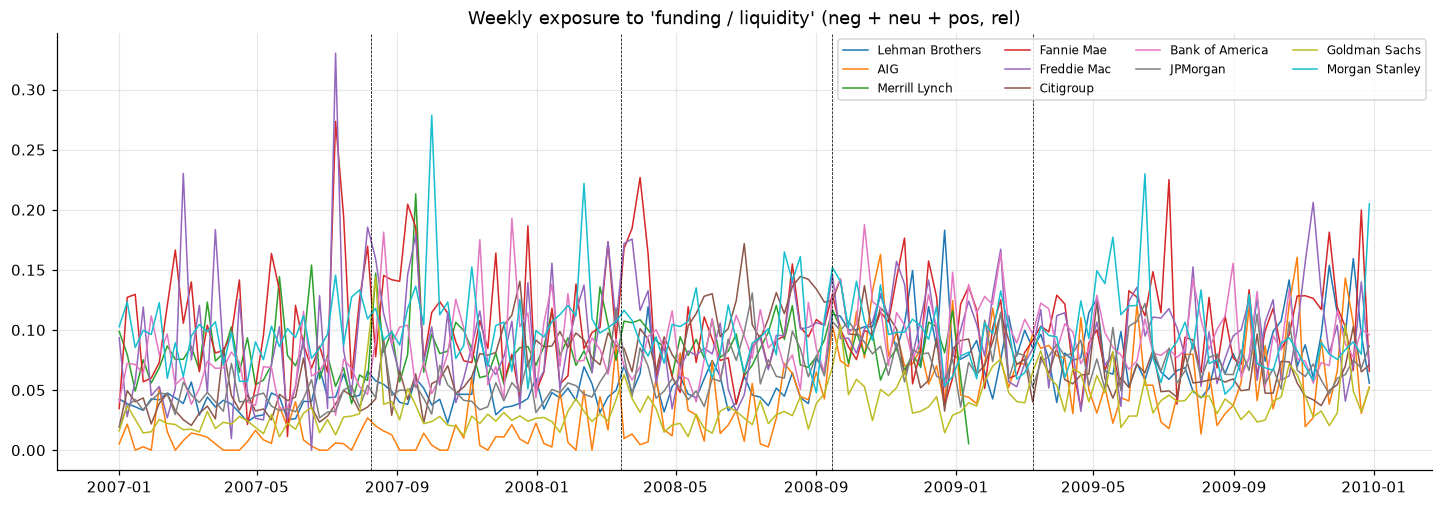

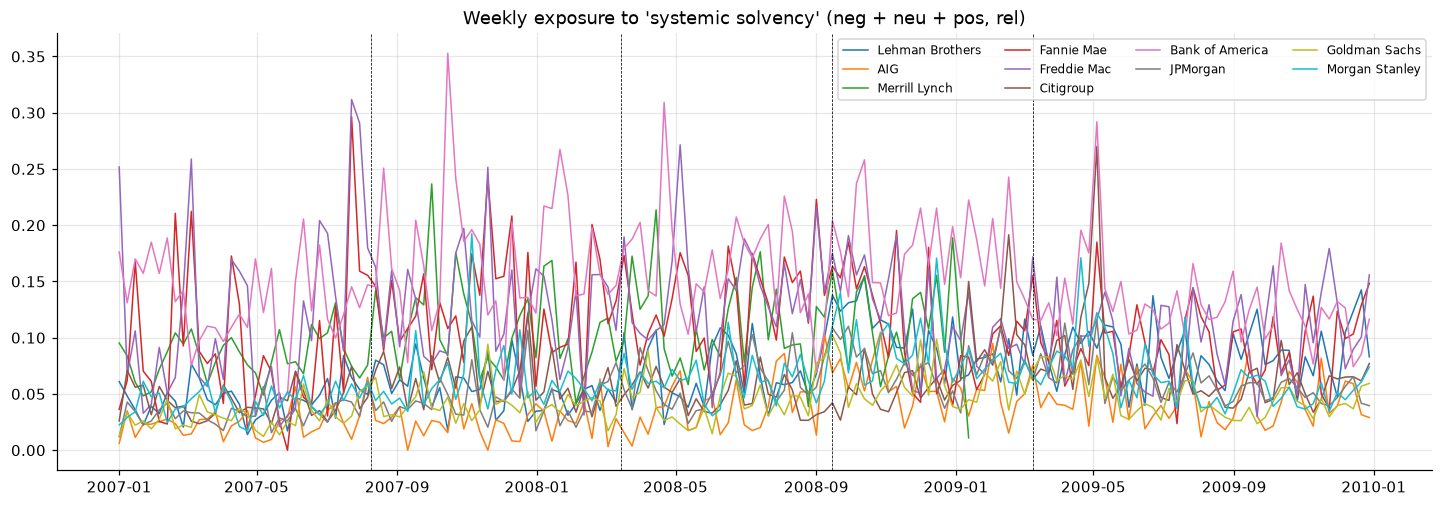

In [13]:
def weekly_exposure(case, battery, labels) -> None:
    keys = battery_keys(case["batteries"][battery])
    raw = KEYMAP.filter(pl.col("MERGED").is_in(keys))[KEY].to_list()
    ids = list(case["names"].values())
    lo, hi = case["view"]
    num = (NA.filter(_between(case["view"]), pl.col("SENTIMENT").is_in(list(labels)),
                     pl.col(KEY).is_in(raw), pl.col("RP_ENTITY_ID").is_in(ids))
           .group_by(pl.col("DATE").dt.truncate("1w").alias("WEEK"), "RP_ENTITY_ID")
           .agg(pl.col(VARIANTS[CASE_VARIANT][0]).sum().alias("T")).collect())
    den = (AA.filter(_between(case["view"]), pl.col("SENTIMENT").is_in(list(labels)),
                     pl.col("RP_ENTITY_ID").is_in(ids))
           .group_by(pl.col("DATE").dt.truncate("1w").alias("WEEK"), "RP_ENTITY_ID")
           .agg(pl.col(VARIANTS[CASE_VARIANT][2]).sum().alias("N_STORIES")).collect())
    if den.is_empty():
        print(f"{battery}: no data in the view yet")
        return
    w = (den.join(num, on=["WEEK", "RP_ENTITY_ID"], how="left")
         .with_columns((pl.col("T").fill_null(0) / pl.max_horizontal(pl.col("N_STORIES"), pl.lit(SHRINK)))
                       .alias("exposure")).sort("WEEK"))
    fig, ax = plt.subplots(figsize=(13, 4.5))
    for label, eid in case["names"].items():
        s = w.filter(pl.col("RP_ENTITY_ID") == eid)
        ax.plot(s["WEEK"], s["exposure"], lw=1, label=label)
    for name, d in case["events"].items():
        ax.axvline(d, color="k", lw=0.5, ls="--")
    ax.legend(ncols=4, fontsize=8)
    ax.set_title(f"Weekly exposure to '{battery}' ({' + '.join(labels)}, {CASE_VARIANT})")
    plt.show()


weekly_exposure(GFC, "funding / liquidity", STUDIES["Attention"])
weekly_exposure(GFC, "systemic solvency", STUDIES["Attention"])

# Part 4: Covid (2020-02-15 → 2020-06-30)

## 4.1 The most central stocks of the Covid batteries

Expected: airlines, cruise lines and hotels central in the health shock; oil majors and
producers in the oil / demand collapse; vaccine makers in the recovery battery.

In [14]:
for battery in COVID["batteries"]:
    print(f"\n=== {battery} (Attention) ===")
    print(battery_table(COVID, battery, STUDIES["Attention"]))


=== health shock (Attention) ===
shape: (15, 8)
┌──────────────────────────────┬────────┬────────────────────────┬────────────────┬───────────────────┬─────────────────┬─────────────────┬───────────────┐
│ name                         ┆ ticker ┆ gics_sector            ┆ support_window ┆ centrality_window ┆ centrality_base ┆ exposure_window ┆ exposure_base │
│ ---                          ┆ ---    ┆ ---                    ┆ ---            ┆ ---               ┆ ---             ┆ ---             ┆ ---           │
│ str                          ┆ str    ┆ str                    ┆ i32            ┆ f64               ┆ f64             ┆ f64             ┆ f64           │
╞══════════════════════════════╪════════╪════════════════════════╪════════════════╪═══════════════════╪═════════════════╪═════════════════╪═══════════════╡
│ Meta Platforms, Inc.         ┆ META   ┆ Communication Services ┆ 42846          ┆ 0.0053            ┆ 0.0075          ┆ 0.0621          ┆ 0.0272        │
│ AT&T Inc.    

## 4.2 What travel, energy and health names' news was about

In [15]:
for label, t in top_narratives(COVID, STUDIES["Attention"]).items():
    print(f"\n--- {label} ---")
    print(t)


--- Delta ---
shape: (8, 7)
┌──────────────────────────────────────┬────────────────────────────────────┬──────┬──────────┬────────┬───────────────┬──────┐
│ merged_name                          ┆ dimension                          ┆ S    ┆ exposure ┆ se     ┆ exposure_base ┆ lift │
│ ---                                  ┆ ---                                ┆ ---  ┆ ---      ┆ ---    ┆ ---           ┆ ---  │
│ str                                  ┆ str                                ┆ i32  ┆ f64      ┆ f64    ┆ f64           ┆ f64  │
╞══════════════════════════════════════╪════════════════════════════════════╪══════╪══════════╪════════╪═══════════════╪══════╡
│ transport-and-logistics-incident     ┆ operating-incident-condition       ┆ 3179 ┆ 0.1327   ┆ 0.0018 ┆ 0.0993        ┆ 17.4 │
│ state-security-imposition            ┆ domestic-order-and-state-security  ┆ 2759 ┆ 0.1236   ┆ 0.0019 ┆ 0.0712        ┆ 7.8  │
│ health-fear-and-contagion-salience   ┆ public-health-condition           

## 4.3 Negative vs positive + neutral exposure

In [16]:
print(tone_by_battery(COVID))

shape: (48, 5)
┌───────────────────┬───────────────────────────┬──────────┬────────────────────┬───────────┐
│ case_name         ┆ battery                   ┆ Negative ┆ Positive + neutral ┆ neg_share │
│ ---               ┆ ---                       ┆ ---      ┆ ---                ┆ ---       │
│ str               ┆ str                       ┆ f64      ┆ f64                ┆ f64       │
╞═══════════════════╪═══════════════════════════╪══════════╪════════════════════╪═══════════╡
│ American Airlines ┆ health shock              ┆ 0.1157   ┆ 0.0939             ┆ 0.55      │
│ Carnival          ┆ health shock              ┆ 0.0593   ┆ 0.0232             ┆ 0.72      │
│ Chevron           ┆ health shock              ┆ 0.0081   ┆ 0.0251             ┆ 0.24      │
│ Delta             ┆ health shock              ┆ 0.099    ┆ 0.0756             ┆ 0.57      │
│ Exxon             ┆ health shock              ┆ 0.0046   ┆ 0.0089             ┆ 0.34      │
│ Marriott          ┆ health shock           

## 4.4 Weekly exposure to the health shock and the oil collapse

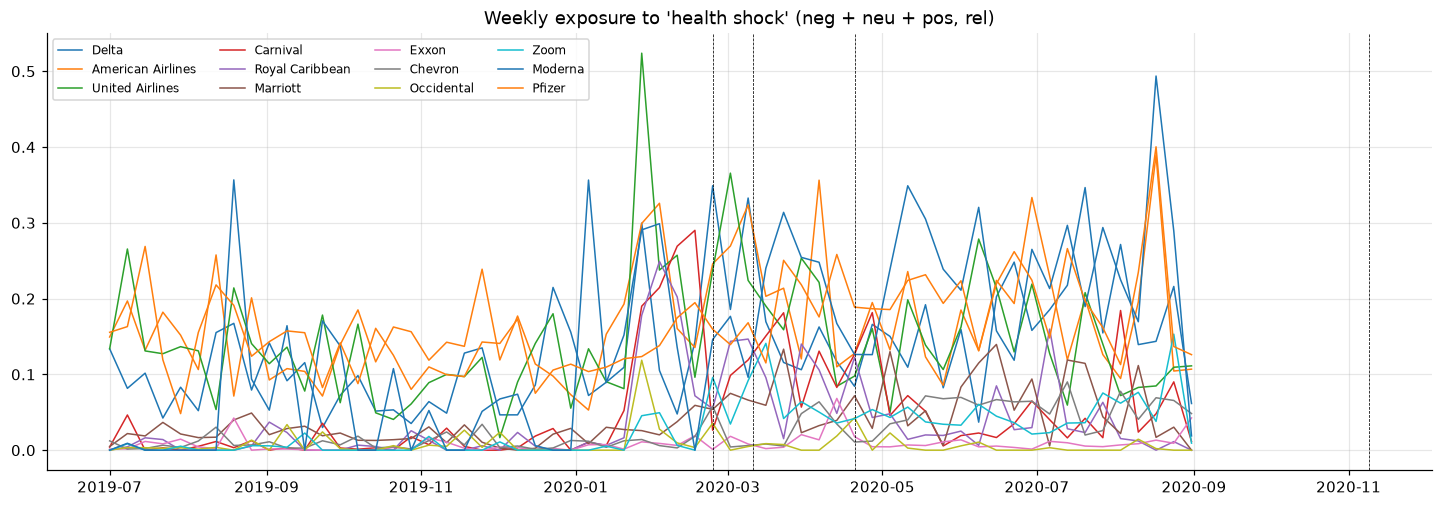

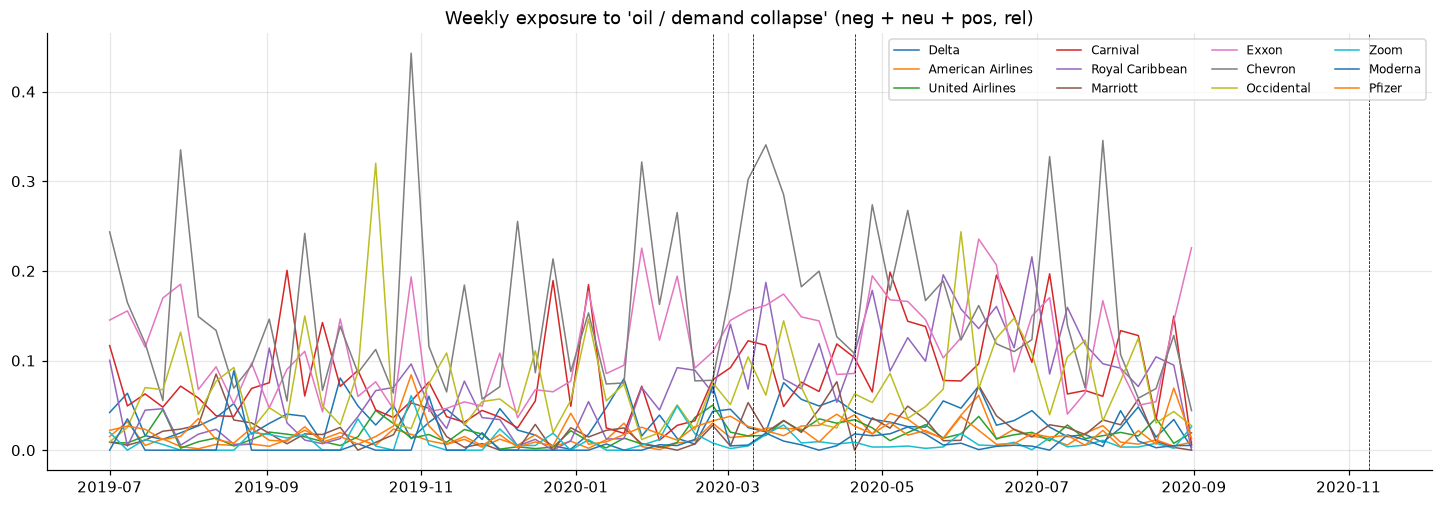

In [17]:
weekly_exposure(COVID, "health shock", STUDIES["Attention"])
weekly_exposure(COVID, "oil / demand collapse", STUDIES["Attention"])